# Didactic model 
This notebook reimplements the core model mechanics needed to reproduce the Figure 5d-style output: mean learned value trajectories for CS+ and CS-, with (solid) and without (dashed) MDN-like feedback. 

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax

plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Set model and environment parameters

In [2]:
## Simulation Parameters

S = 11  # Number of spatial states in the 1D arena.
T = 1000  # Number of timesteps.
SCENTER = math.floor(S / 2)  # Center state.


## Model parameters
N = 2000  # Number of KCs.
N_ACTIVE_KCS = 100  # Number of active KCs per odour (active rate = 1 / N_ACTIVE_KCS).
INITIAL_WEIGHT = 1.0  # Initial KC-to-MBON weight.
ETA = 0.1  # Learning rate in the manuscript.
GAMMA = 0.8  # Temporal discount factor in the manuscript.
DAN_DEPRESSION_THRESHOLD = 1 # c in manuscript, threshold for DAN activity to cause depression so that MBON activity remains positive, c in manuscript
BASELINE_DAN_ACTIVITY = 0.7 # b in manuscript, so that dan and mbon activity is positive, b in manuscript

MDN_SIGNAL = 0.05  # MDN_t when MDN condition is met.
MDN_TO_D_P = 2 # a in manuscript, controls balance of MDN feedback to d_r vs d_p. When 1, all feedback goes to d_p and none to d_r, when 0 all goes to d_r
ACTION_TEMPERATURE = .1 # action probability is softmax([-value_estimate, value_estimate,0]/ACTION_TEMPERATURE)

ACTIONS = np.asarray([1, -1, 0])  # [approach, avoid, stay].

## Set up functions to run the model in the environment

### Model notation used below

This notebook mirrors the variable names and flow in the modelling section of the methods:

- `k_t`: KC activity; odours activate non-overlapping KC subsets, active rate `1` inactive rate `0`.
- `m_ap`, `m_av`: approach and avoidance MBON activities.
- `V = m_ap - m_av`: current odour value estimate used for action selection.
- `pi_ap`, `pi_av`: temporal prediction components using `gamma` and consecutive KC patterns.
- `d_p`, `d_r`: punishment- and reward-responsive DAN activities, including optional MDN terms.
- `w_ap`, `w_av`: KC-to-MBON weights updated with learning rate `eta` and subtractive normalization toward `WEIGHT_SUM_TARGET`.
- `b`: DAN balance term in the external reward/punishment drive.

In [3]:
def build_odor_map(rng):
    """
    Randomly select KCs sparsely active in each odor and map KC activity to each state in the environment.
    The first half of states are associated with odor 1 and the second half with odor 2, with no overlap in active KCs between odors.

    Args:
        rng: NumPy random generator used to sample KC subsets.

    Returns:
        kc_activity_by_state: Array of shape (S, N) with state-dependent KC activity.
        odor_1_activity: Binary KC activity vector for odor 1.
        odor_2_activity: Binary KC activity vector for odor 2.
    """
    if 2 * N_ACTIVE_KCS > N:
        raise ValueError('Need at least 2 * N_ACTIVE_KCS total KCs for non-overlapping odour subsets.')

    all_kcs = np.arange(N)
    odor_1_kcs = rng.choice(all_kcs, size=N_ACTIVE_KCS, replace=False)
    remaining_kcs = np.setdiff1d(all_kcs, odor_1_kcs)
    odor_2_kcs = rng.choice(remaining_kcs, size=N_ACTIVE_KCS, replace=False)

    odor_1_activity = np.zeros(N)
    odor_2_activity = np.zeros(N)
    odor_1_activity[odor_1_kcs] = 1.0 
    odor_2_activity[odor_2_kcs] = 1.0 

    kc_activity_by_state = np.zeros((S, N))
    kc_activity_by_state[: math.floor(S / 2), :] = odor_1_activity
    kc_activity_by_state[-math.floor(S / 2) :, :] = odor_2_activity
    return kc_activity_by_state, odor_1_activity, odor_2_activity


def is_at_env_end(curr_s):
    """
    Return True if the given spatial state index is at either end of the 1D environment.

    Args:
        curr_s (int): Current spatial state index.

    Returns:
        bool: True if curr_s is 0 or S - 1, False otherwise.
    """
    return (curr_s == 0) or (curr_s == S - 1)


def get_action_probabilities(value_estimate):
    """
    Compute action probabilities using softmax over value estimates for each action.
    
    Args:
        value_estimate (float): Current odour value estimate (m_ap - m_av).
    
    Returns:
        np.ndarray: Probability distribution over actions [approach, avoid, stay].
    """
    return softmax(np.asarray([value_estimate, -value_estimate, 0]) / ACTION_TEMPERATURE)


def choose_action(value_estimate):
    """
    Compute action probabilities from the current value estimate and choose an action.

    Args:
        value_estimate (float): Current odour value estimate (m_ap - m_av).

    Returns:
        int: Selected action sampled from ACTIONS according to softmax probabilities.
    """
    return np.random.choice(ACTIONS, p=get_action_probabilities(value_estimate))

def model_update(k_t, k_prev, m_ap, m_av, w_av, w_ap, d_r, d_p, r, p, mdn): 
    """
    Update MBON weights, activities, value estimate, and DAN signals for one timestep.

    Args:
        k_t: Current KC activity vector.
        k_prev: Previous KC activity vector used for synaptic update.
        m_ap: Current approach MBON activity.
        m_av: Current avoidance MBON activity.
        w_av: KC-to-avoidance weights.
        w_ap: KC-to-approach weights.
        d_r: Current reward-sensitive DAN activity.
        d_p: Current punishment-sensitive DAN activity.
        r: External reward signal.
        p: External punishment signal.
        mdn: MDN feedback signal.

    Returns:
        Updated w_av, w_ap, m_av, m_ap, V, d_r, d_p.
    """
    w_av = w_av - ETA/N_ACTIVE_KCS * (d_r - DAN_DEPRESSION_THRESHOLD) * k_prev
    w_ap = w_ap - ETA/N_ACTIVE_KCS * (d_p - DAN_DEPRESSION_THRESHOLD) * k_prev

    m_ap_prev = m_ap
    m_av_prev = m_av
    
    m_ap = w_ap @ k_t 
    m_av = w_av @ k_t
    V = m_ap - m_av

    pi_ap = GAMMA * m_ap - m_ap_prev
    pi_av = GAMMA * m_av - m_av_prev

    d_p = p - pi_ap + MDN_TO_D_P * mdn + BASELINE_DAN_ACTIVITY
    d_r = r - pi_av + (MDN_TO_D_P-1)*mdn + BASELINE_DAN_ACTIVITY
    return w_av, w_ap, m_av, m_ap, V, d_r, d_p


def run_minimal_simulation(seed, mdn_feedback=False):
    """
    Run a minimal training simulation of the agent in the 1D environment.

    Args:
        seed (int): RNG seed for reproducibility.
        mdn_feedback (bool): If True, provide MDN feedback signal on avoidance actions.

    Returns:
        tuple: (odor_values, rs, m_av_odor_responses, m_ap_odor_responses, ss)
            odor_values (np.ndarray): Shape (T,2), odour value traces over time.
            rs (np.ndarray): Shape (T,), reinforcement received each timestep.
            m_av_odor_responses (np.ndarray): Shape (T,2), avoidance MBON responses to odors.
            m_ap_odor_responses (np.ndarray): Shape (T,2), approach MBON responses to odors.
            ss (np.ndarray): Shape (T,), spatial state index at each timestep.
    """
    if not isinstance(mdn_feedback, bool):
        raise TypeError('mdn_feedback must be a boolean (True or False)')

    np.random.seed(seed)
    subset_rng = np.random.default_rng(seed)  # Isolated stream so KC sampling does not shift action randomness.


    reinforcement_by_state = np.zeros(S)
    reinforcement_by_state[0] = 1.0
    reinforcement_by_state[-1] = -1.0
    rs = np.zeros(T)


    kc_activity_by_state, odor_1_activity, odor_2_activity = build_odor_map(subset_rng)

    odor_values = np.zeros((T, 2))
    m_ap_odor_responses= np.zeros((T,2))
    m_av_odor_responses = np.zeros((T,2))
    ss = np.zeros(T, dtype=int)
    s = SCENTER

    w_ap = np.ones(N) * (INITIAL_WEIGHT / N_ACTIVE_KCS)
    w_av = np.ones(N) * (INITIAL_WEIGHT / N_ACTIVE_KCS)

    k_t = np.copy(kc_activity_by_state[s])
    m_ap = w_ap @ k_t
    m_av = w_av @ k_t
    V = m_ap - m_av
    k_prev = k_t
    d_r = d_p = BASELINE_DAN_ACTIVITY

    for t in range( T ):
        ss[t] = s

        reinforcement_t = reinforcement_by_state[s]

        if is_at_env_end(s):
            s = SCENTER
            current_action = 0
        else:
            current_action = choose_action(V)
            if s < SCENTER:
                current_action = -current_action
            s = s + current_action

        k_prev_prev = np.copy(k_prev)
        k_prev = np.copy(k_t)
        k_t = np.copy(kc_activity_by_state[s])

        r = max(reinforcement_t, 0.0) # external reward
        p = max(-reinforcement_t, 0.0) # external punishment

        mdn = 0.0
        if mdn_feedback and current_action == -1:#and V[t] < -VALUE_THRESHOLD:
            mdn = MDN_SIGNAL

        w_av, w_ap, m_av, m_ap, V, d_r, d_p = model_update(
            k_t, k_prev_prev, m_ap, m_av, w_av, w_ap, d_r, d_p, r, p, mdn)


        odor_values[t] = [
            (w_ap - w_av) @ odor_1_activity,
            (w_ap - w_av) @ odor_2_activity,
        ]

        m_av_odor_responses[t] = [
            w_av @ odor_1_activity,
            w_av @ odor_2_activity,
        ]
        m_ap_odor_responses[t] = [
            w_ap @ odor_1_activity,
            w_ap @ odor_2_activity,
        ]

        rs[t] = reinforcement_t
    return odor_values,  rs, m_av_odor_responses, m_ap_odor_responses, ss


## Run the model and plot results

In [4]:
SEED = 12
T=400
W_no_mdn_feedback, endzone_no_mdn_feedback, m_av_no_mdn_feedback, m_ap_no_mdn_feedback, states = run_minimal_simulation(seed=SEED, mdn_feedback=False)
W_with_mdn_feedback, endzone_with_mdn_feedback, m_av_with_mdn_feedback, m_ap_with_mdn_feedback, states = run_minimal_simulation(seed=SEED, mdn_feedback=True)

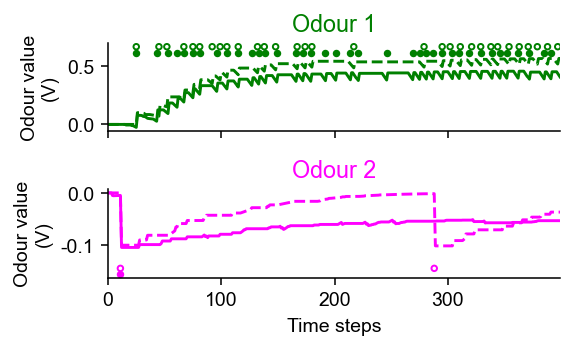

In [5]:
def plot_values(ax, W, endzone, T, valmax, valmin, odor, dashed_line=False, alpha=1.0):
    col = 'green' if odor == 0 else 'magenta'
    ls = '--' if dashed_line else '-'
    ax.plot(W[:, odor], color=col, ls=ls, alpha=alpha)

    rtime = endzone > 0
    ptime = endzone < 0

    if odor == 0:
        ax.scatter(
            np.arange(T)[rtime],
            valmax * np.ones(np.sum(rtime)) + 0.05 * int(dashed_line),
            color=col,
            s=8,
            alpha=alpha,
            facecolors='none' if dashed_line else col,
        )
    else:
        ax.scatter(
            np.arange(T)[ptime],
            valmin * np.ones(np.sum(ptime)) + 0.01 * int(dashed_line),
            color=col,
            s=8,
            alpha=alpha,
            facecolors='none' if dashed_line else col,
        )


valmax = np.max(np.concatenate([W_no_mdn_feedback.reshape(-1), W_with_mdn_feedback.reshape(-1)])) + 0.05
valmin = np.min(np.concatenate([W_no_mdn_feedback.reshape(-1), W_with_mdn_feedback.reshape(-1)])) - 0.05

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(4.2, 2.6))

# Dashed: no MDN feedback
plot_values(axs[0], W_no_mdn_feedback, endzone_no_mdn_feedback.astype(int), T, valmax, valmin, odor=0, dashed_line=True, alpha=1.0)
plot_values(axs[1], W_no_mdn_feedback, endzone_no_mdn_feedback.astype(int), T, valmax, valmin, odor=1, dashed_line=True, alpha=1.0)

# Solid: with MDN feedback
plot_values(axs[0], W_with_mdn_feedback, endzone_with_mdn_feedback.astype(int), T, valmax, valmin, odor=0, dashed_line=False, alpha=1.0)
plot_values(axs[1], W_with_mdn_feedback, endzone_with_mdn_feedback.astype(int), T, valmax, valmin, odor=1, dashed_line=False, alpha=1.0)

axs[0].set_ylabel('Odour value\n(V)')
axs[1].set_ylabel('Odour value\n(V)')
axs[0].set_title('Odour 1', color='green')
axs[1].set_title('Odour 2', color='magenta')
axs[1].set_xlabel('Time steps')

for ax in axs:
    ax.set_xlim(0, T - 1)
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FormatStrFormatter('%.1f'))

fig.tight_layout()
plt.show()